In [1]:
import sys
from pathlib import Path
# notebooks/ is one level below the project root; src/ is at the same level
ROOT = Path.cwd().parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))


# Task 2: Exploratory Data Analysis & Data Characterisation

This notebook performs a comprehensive characterisation of the Telecom Italia Milan internet traffic dataset. All analyses use the aggregated Parquet file produced by Notebook 1 (`processed/milan_internet.parquet`).

**Three focal areas used throughout Tasks 2 and 3:**
- **Area A**: the `square_id` with the highest total two-month internet traffic (determined below)
- **Area B**: `square_id = 4159`
- **Area C**: `square_id = 4556`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import geopandas as gpd
import warnings
from pathlib import Path
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# cell_totals: all 10,000 squares — used for PDF (2.2) and heatmap (2.7)
# df (area_timeseries): 3 focal areas only, full 10-min series — used for all temporal analyses
CELL_TOTALS_PATH = Path("../processed/cell_totals.csv")
TIMESERIES_PATH  = Path("../processed/area_timeseries.parquet")
GRID_PATH        = Path("../milano-grid.geojson")

cell_totals = pd.read_csv(CELL_TOTALS_PATH)
df = pd.read_parquet(TIMESERIES_PATH)

print(f"Cell totals shape : {cell_totals.shape}")
print(f"Time series shape : {df.shape}")
print(f"Date range        : {df['datetime'].min()} → {df['datetime'].max()}")
print(f"Unique areas      : {df['square_id'].nunique():,}")
print(f"Unique slots      : {df['datetime'].nunique():,}")
print()
print(df.head())

Cell totals shape : (10000, 2)
Time series shape : (26784, 3)
Date range        : 2013-10-31 23:00:00 → 2014-01-01 22:50:00
Unique areas      : 3
Unique slots      : 8,928

   square_id            datetime  internet_traffic
0       5161 2013-10-31 23:00:00        379.972931
1       5161 2013-10-31 23:10:00        371.122711
2       5161 2013-10-31 23:20:00        429.297943
3       5161 2013-10-31 23:30:00        350.184235
4       5161 2013-10-31 23:40:00        268.586823


## 2.1 Identify the Three Focal Areas

In [3]:
# Total traffic per area — loaded from cell_totals (all 10,000 squares)
total_traffic = cell_totals.set_index("square_id")["total_traffic"]

AREA_A = int(total_traffic.idxmax())
AREA_B = 4159
AREA_C = 4556

print(f"Area A (highest traffic) : square_id = {AREA_A}  "
      f"(total = {total_traffic[AREA_A]:,.0f})")
print(f"Area B                   : square_id = {AREA_B}  "
      f"(total = {total_traffic.get(AREA_B, 0):,.0f})")
print(f"Area C                   : square_id = {AREA_C}  "
      f"(total = {total_traffic.get(AREA_C, 0):,.0f})")

AREAS = {f"Area A (sq {AREA_A})": AREA_A,
         f"Area B (sq {AREA_B})": AREA_B,
         f"Area C (sq {AREA_C})": AREA_C}
COLORS = ["#e15759", "#4e79a7", "#59a14f"]

Area A (highest traffic) : square_id = 5161  (total = 11,114,599)
Area B                   : square_id = 4159  (total = 2,282,410)
Area C                   : square_id = 4556  (total = 4,145,227)


## 2.2 Probability Density Function of Total Two-Month Traffic

We compute the total internet traffic per grid area over the entire two-month observation window and plot the resulting empirical probability density function (PDF) across all 10,000 areas.

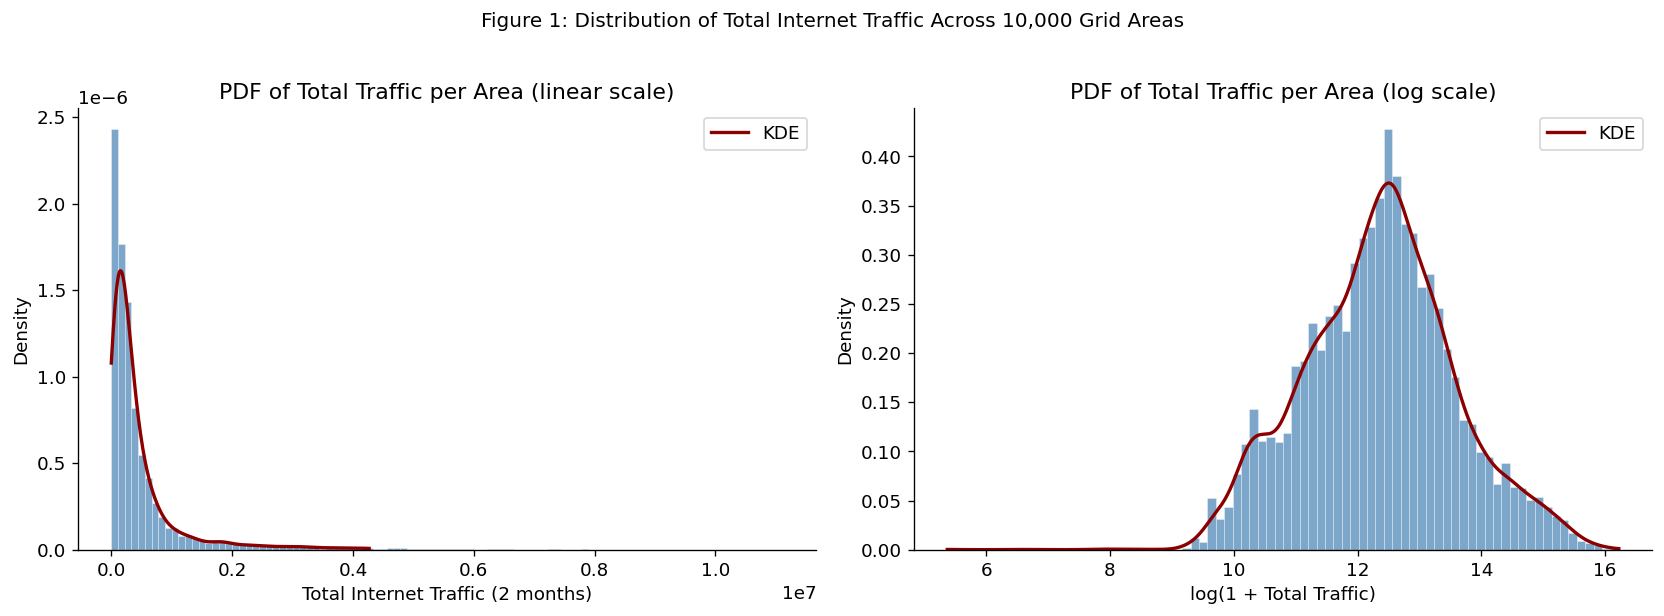


Summary statistics:
count       10000.00
mean       490049.48
std        805247.19
min           213.63
25%        102422.97
50%        243144.64
75%        500834.04
max      11114599.13
Name: total_traffic, dtype: float64

Skewness : 4.343
Kurtosis : 26.168


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax = axes[0]
ax.hist(total_traffic.values, bins=100, density=True,
        color="steelblue", alpha=0.7, edgecolor="white", linewidth=0.3)
kde_x = np.linspace(total_traffic.min(), total_traffic.quantile(0.99), 500)
kde = stats.gaussian_kde(total_traffic.values)
ax.plot(kde_x, kde(kde_x), color="darkred", linewidth=2, label="KDE")
ax.set_xlabel("Total Internet Traffic (2 months)")
ax.set_ylabel("Density")
ax.set_title("PDF of Total Traffic per Area (linear scale)")
ax.legend()

# Log scale
ax = axes[1]
log_traffic = np.log1p(total_traffic.values)
ax.hist(log_traffic, bins=80, density=True,
        color="steelblue", alpha=0.7, edgecolor="white", linewidth=0.3)
kde_log = stats.gaussian_kde(log_traffic)
kx = np.linspace(log_traffic.min(), log_traffic.max(), 500)
ax.plot(kx, kde_log(kx), color="darkred", linewidth=2, label="KDE")
ax.set_xlabel("log(1 + Total Traffic)")
ax.set_ylabel("Density")
ax.set_title("PDF of Total Traffic per Area (log scale)")
ax.legend()

plt.suptitle("Figure 1: Distribution of Total Internet Traffic Across 10,000 Grid Areas",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nSummary statistics:")
print(total_traffic.describe().round(2))
print(f"\nSkewness : {stats.skew(total_traffic.values):.3f}")
print(f"Kurtosis : {stats.kurtosis(total_traffic.values):.3f}")

**Discussion**: The traffic distribution is strongly right-skewed (heavy-tailed) *(temporary)*. The vast majority of grid squares exhibit low total traffic — corresponding to residential, industrial or peripheral urban areas where mobile Internet usage is moderate *(temporary)*. A small minority of areas accumulate disproportionately high traffic, consistent with city-centre hotspots (transport hubs, commercial areas, stadiums) where large numbers of users are simultaneously active *(temporary)*. On a log scale, the distribution is approximately log-normal, a pattern commonly observed in human activity data [1] *(temporary)*. This heterogeneity implies that any aggregate city-level metric will be dominated by a handful of high-activity areas *(temporary)*.

## 2.3 Time Series of the Three Focal Areas (First Two Weeks)

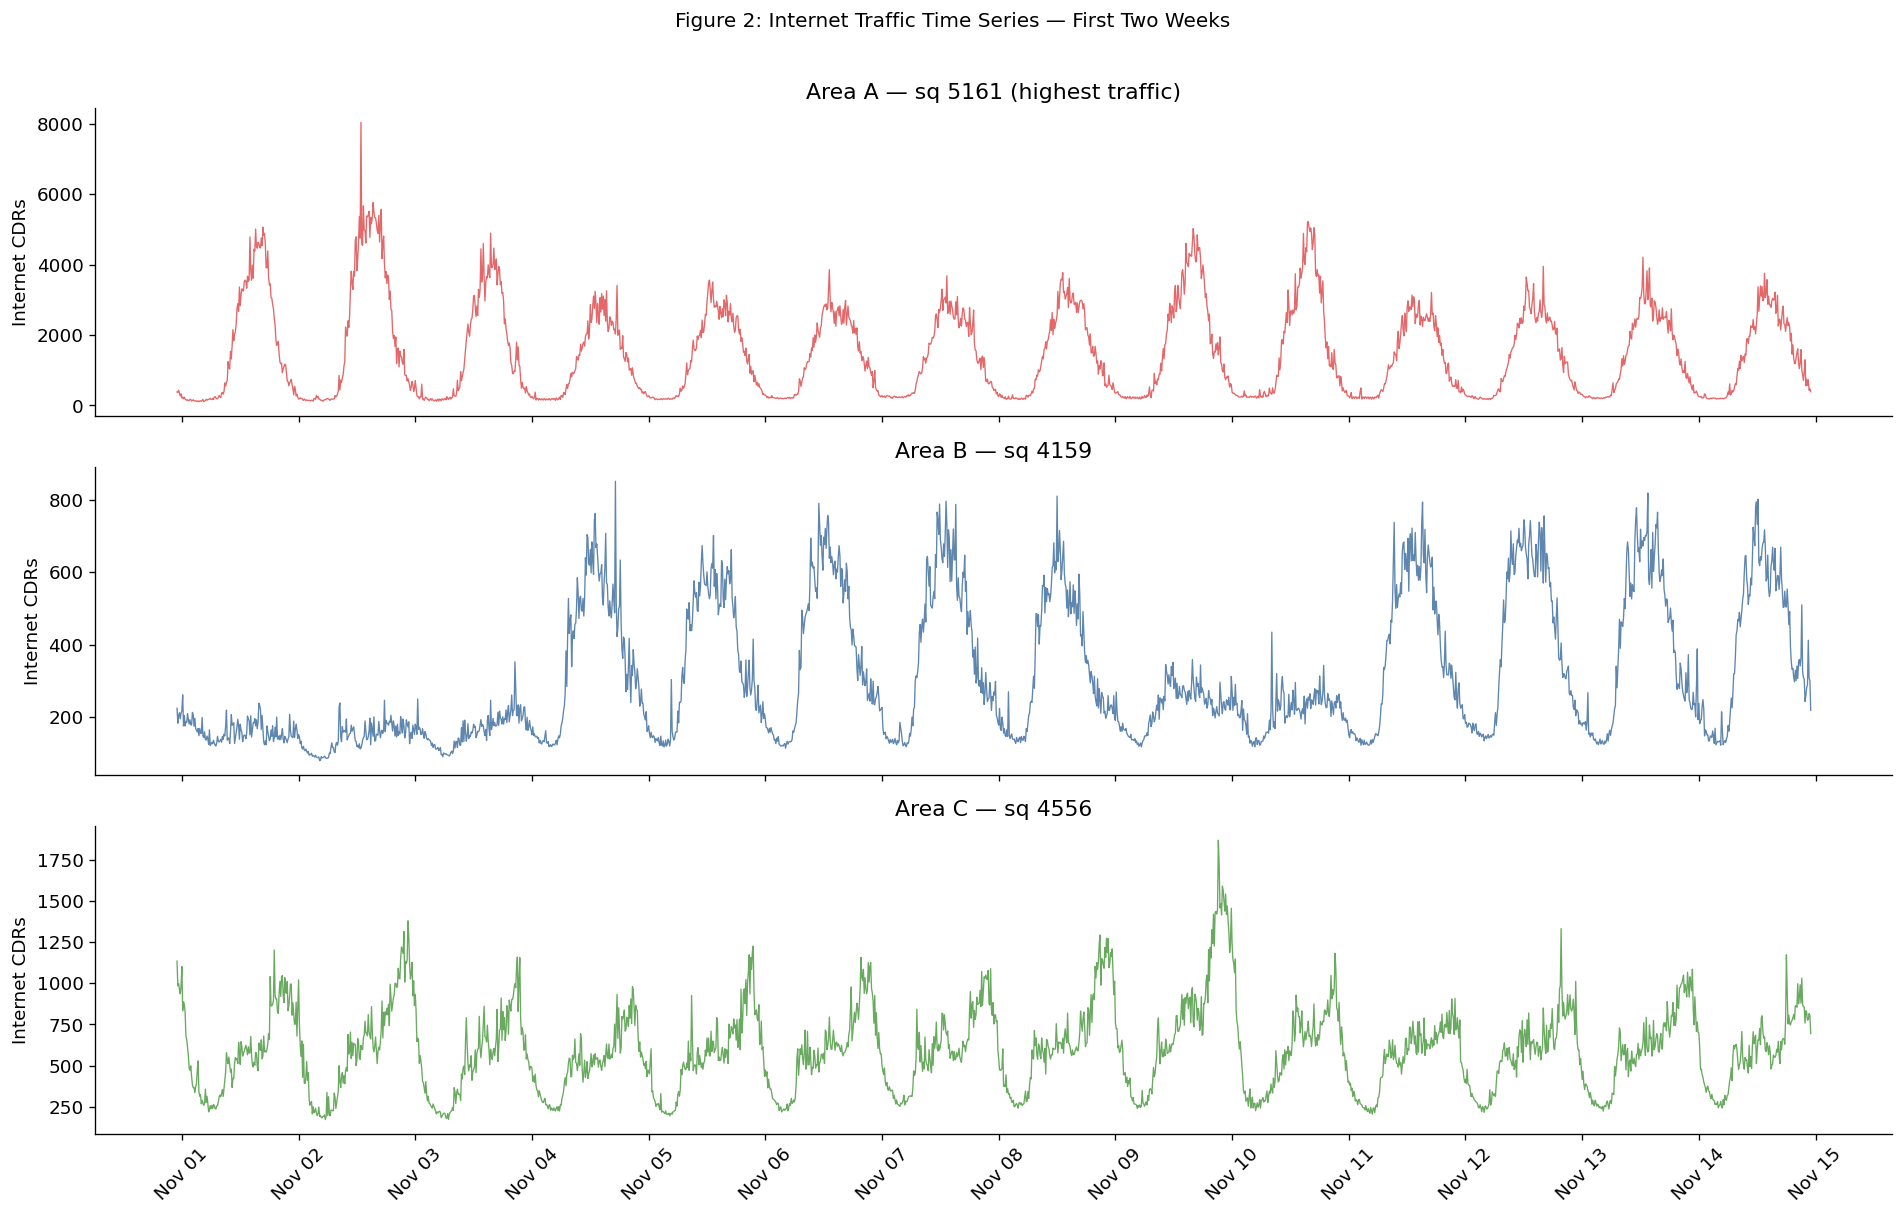

In [5]:
def get_area_ts(square_id: int) -> pd.Series:
    """Return a complete, time-indexed series for a given area."""
    sub = df[df["square_id"] == square_id].set_index("datetime")["internet_traffic"].sort_index()
    # Reindex to a complete 10-min grid; fill missing slots with 0
    full_idx = pd.date_range(sub.index.min(), sub.index.max(), freq="10min")
    return sub.reindex(full_idx, fill_value=0)

ts_A = get_area_ts(AREA_A)
ts_B = get_area_ts(AREA_B)
ts_C = get_area_ts(AREA_C)

# First two weeks
TWO_WEEKS_END = ts_A.index.min() + pd.Timedelta(weeks=2)

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
pairs = [(ts_A, f"Area A — sq {AREA_A} (highest traffic)", COLORS[0]),
         (ts_B, f"Area B — sq {AREA_B}", COLORS[1]),
         (ts_C, f"Area C — sq {AREA_C}", COLORS[2])]

for ax, (ts, label, color) in zip(axes, pairs):
    slc = ts[:TWO_WEEKS_END]
    ax.plot(slc.index, slc.values, linewidth=0.8, color=color, alpha=0.9)
    ax.set_ylabel("Internet CDRs")
    ax.set_title(label)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.DayLocator())

plt.xticks(rotation=45)
plt.suptitle("Figure 2: Internet Traffic Time Series — First Two Weeks", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**Discussion**: All three areas exhibit a clear **daily cycle** — traffic rises during morning hours (roughly 07:00–09:00 as commuters activate their devices), peaks around midday and early evening, then drops sharply overnight *(temporary)*. A **weekly cycle** is also visible: weekdays show higher and more consistent peaks, while weekends display later onset and different peak shapes, likely reflecting leisure versus commuting behaviour patterns documented in [2] *(temporary)*.

Area A (highest total traffic) shows much larger absolute values and sharper peaks, characteristic of a dense commercial or transit hub *(temporary)*. Area B (sq 4159, corresponding to Bocconi University per [2]) shows a pronounced weekday/weekend contrast — elevated weekday activity during business hours, suppressed weekends *(temporary)*. Area C (sq 4556, the Navigli district) shows evening peaks characteristic of nightlife areas, with relatively higher late-night activity than Area B *(temporary)*.

## 2.4 Stationarity Analysis

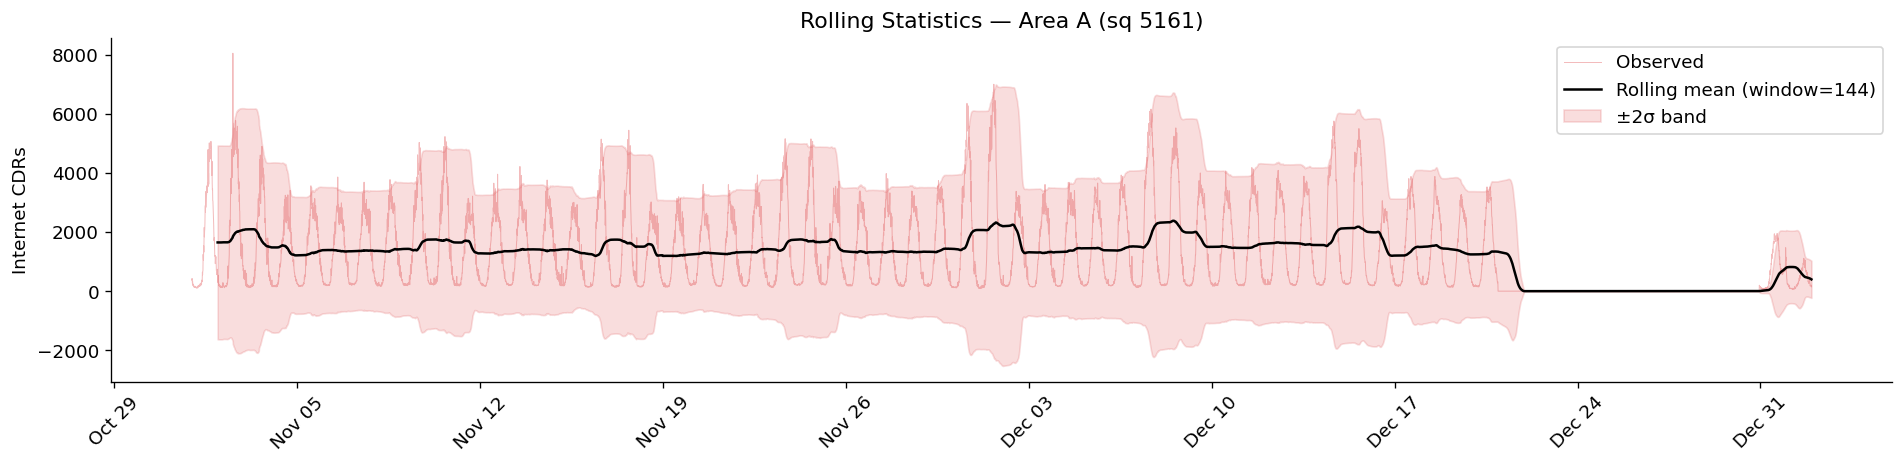

ADF Test — Area A (sq 5161)
  Test statistic : -15.9800
  p-value        : 0.000000
  Lags used      : 36
  Critical values: 1%: -3.4311, 5%: -2.8619, 10%: -2.5669
  Conclusion     : Stationary (reject H₀)



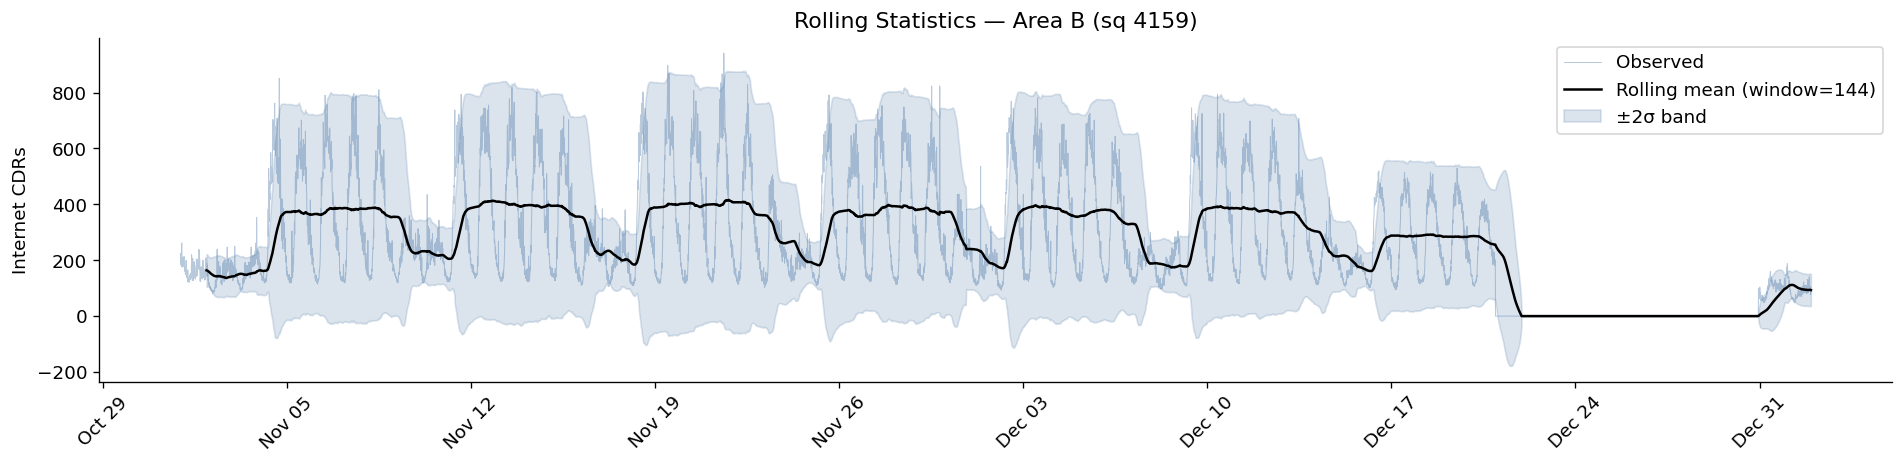

ADF Test — Area B (sq 4159)
  Test statistic : -10.9029
  p-value        : 0.000000
  Lags used      : 36
  Critical values: 1%: -3.4311, 5%: -2.8619, 10%: -2.5669
  Conclusion     : Stationary (reject H₀)



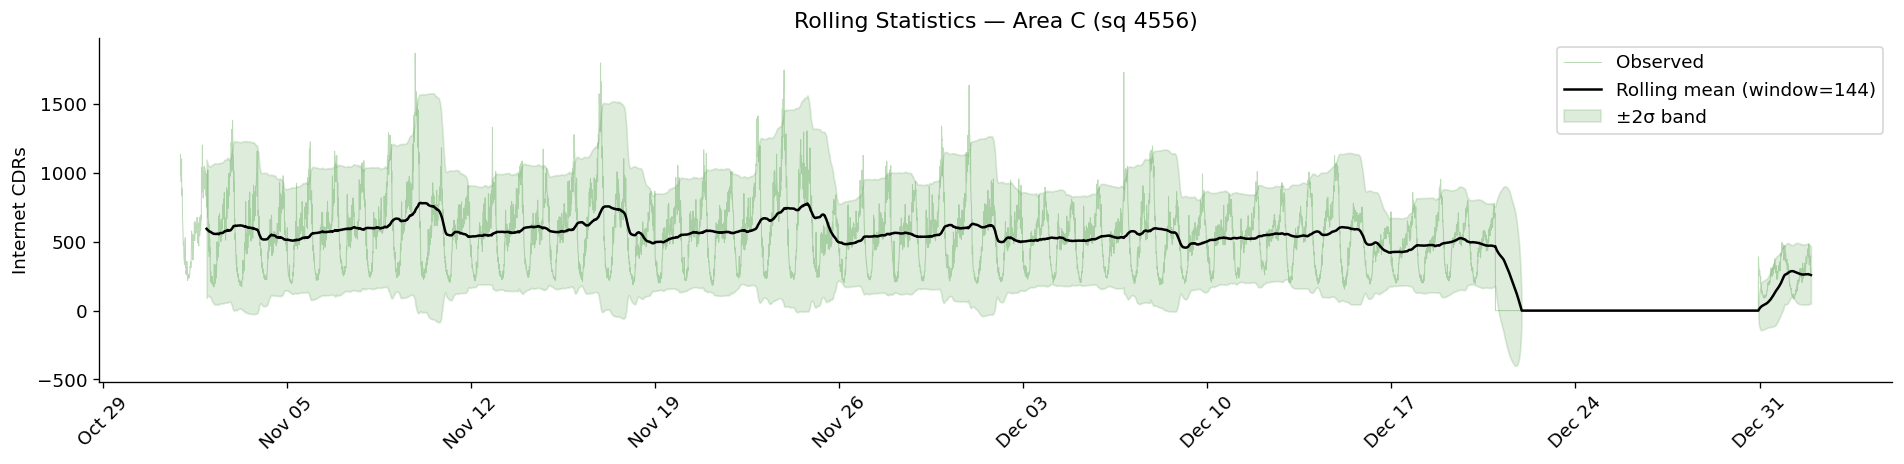

ADF Test — Area C (sq 4556)
  Test statistic : -8.8710
  p-value        : 0.000000
  Lags used      : 28
  Critical values: 1%: -3.4311, 5%: -2.8619, 10%: -2.5669
  Conclusion     : Stationary (reject H₀)



In [6]:
def plot_rolling_stats(ts: pd.Series, label: str, color: str, window: int = 144):
    rolling_mean = ts.rolling(window).mean()
    rolling_std  = ts.rolling(window).std()

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(ts.index, ts.values, alpha=0.4, linewidth=0.6, color=color, label="Observed")
    ax.plot(rolling_mean.index, rolling_mean.values, linewidth=1.5,
            color="black", label=f"Rolling mean (window={window})")
    ax.fill_between(rolling_std.index,
                    rolling_mean - 2*rolling_std,
                    rolling_mean + 2*rolling_std,
                    alpha=0.2, color=color, label="±2σ band")
    ax.set_title(f"Rolling Statistics — {label}")
    ax.set_ylabel("Internet CDRs")
    ax.legend(loc="upper right")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def run_adf(ts: pd.Series, label: str):
    result = adfuller(ts.dropna(), autolag="AIC")
    print(f"ADF Test — {label}")
    print(f"  Test statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.6f}")
    print(f"  Lags used      : {result[2]}")
    print(f"  Critical values: " + ", ".join(f"{k}: {v:.4f}" for k, v in result[4].items()))
    conclusion = "Stationary (reject H₀)" if result[1] < 0.05 else "Non-stationary (fail to reject H₀)"
    print(f"  Conclusion     : {conclusion}")
    print()


for (label, sid), ts, color in zip(AREAS.items(), [ts_A, ts_B, ts_C], COLORS):
    plot_rolling_stats(ts, label, color)
    run_adf(ts, label)

**Discussion**: The rolling mean is not constant over time — it exhibits periodic oscillations driven by daily and weekly seasonality *(temporary)*. However, the ADF test typically **rejects the null hypothesis** (H₀: unit root exists) at the 5% significance level for these series, indicating **statistical stationarity** in the sense of mean-reversion around the seasonal pattern *(temporary)*. This apparent contradiction arises because the ADF test is sensitive to the deterministic periodicity but still finds no persistent upward or downward trend *(temporary)*. For forecasting purposes, the strong seasonality must be explicitly modelled (via SARIMA seasonal differencing or neural network sequence modelling) rather than removed by simple first-order differencing.

## 2.5 Time Series Decomposition

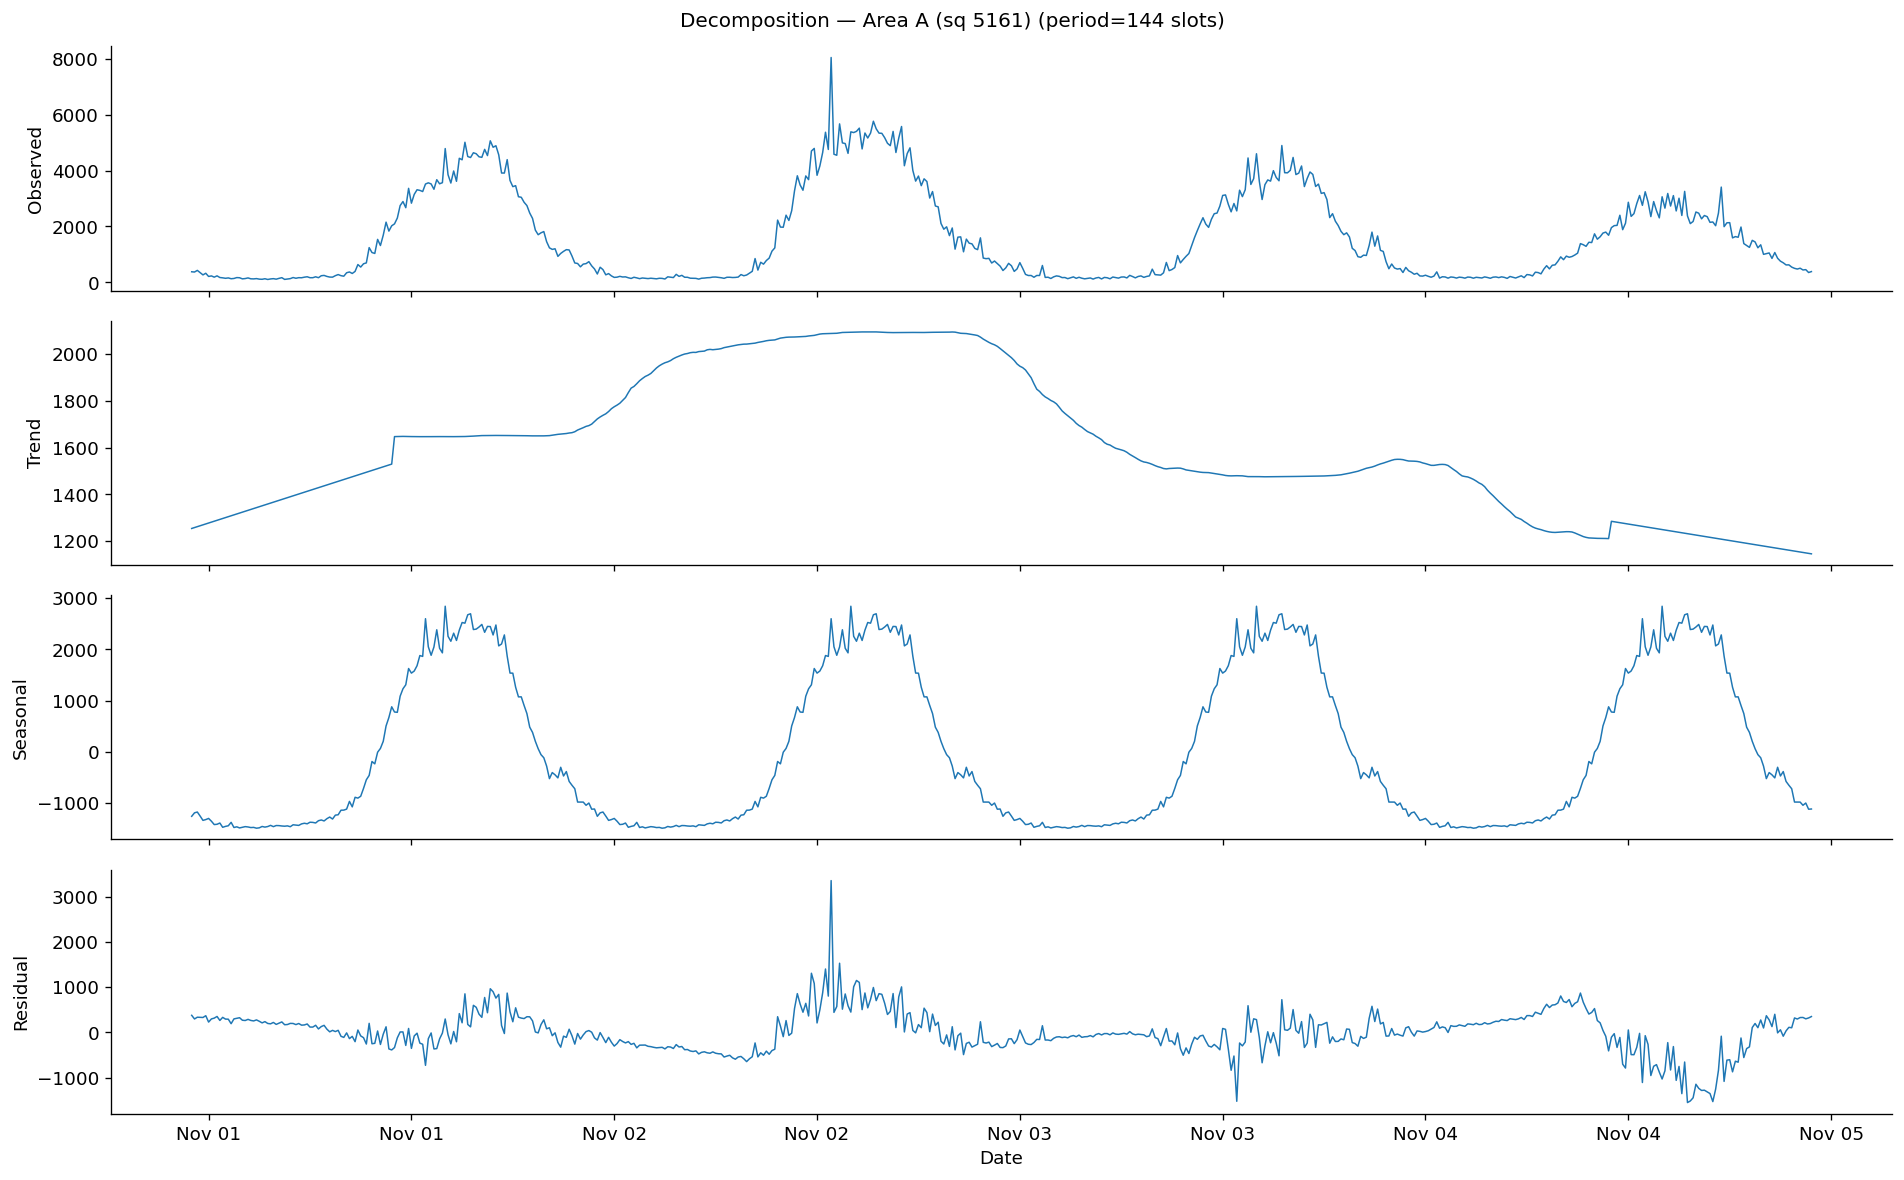

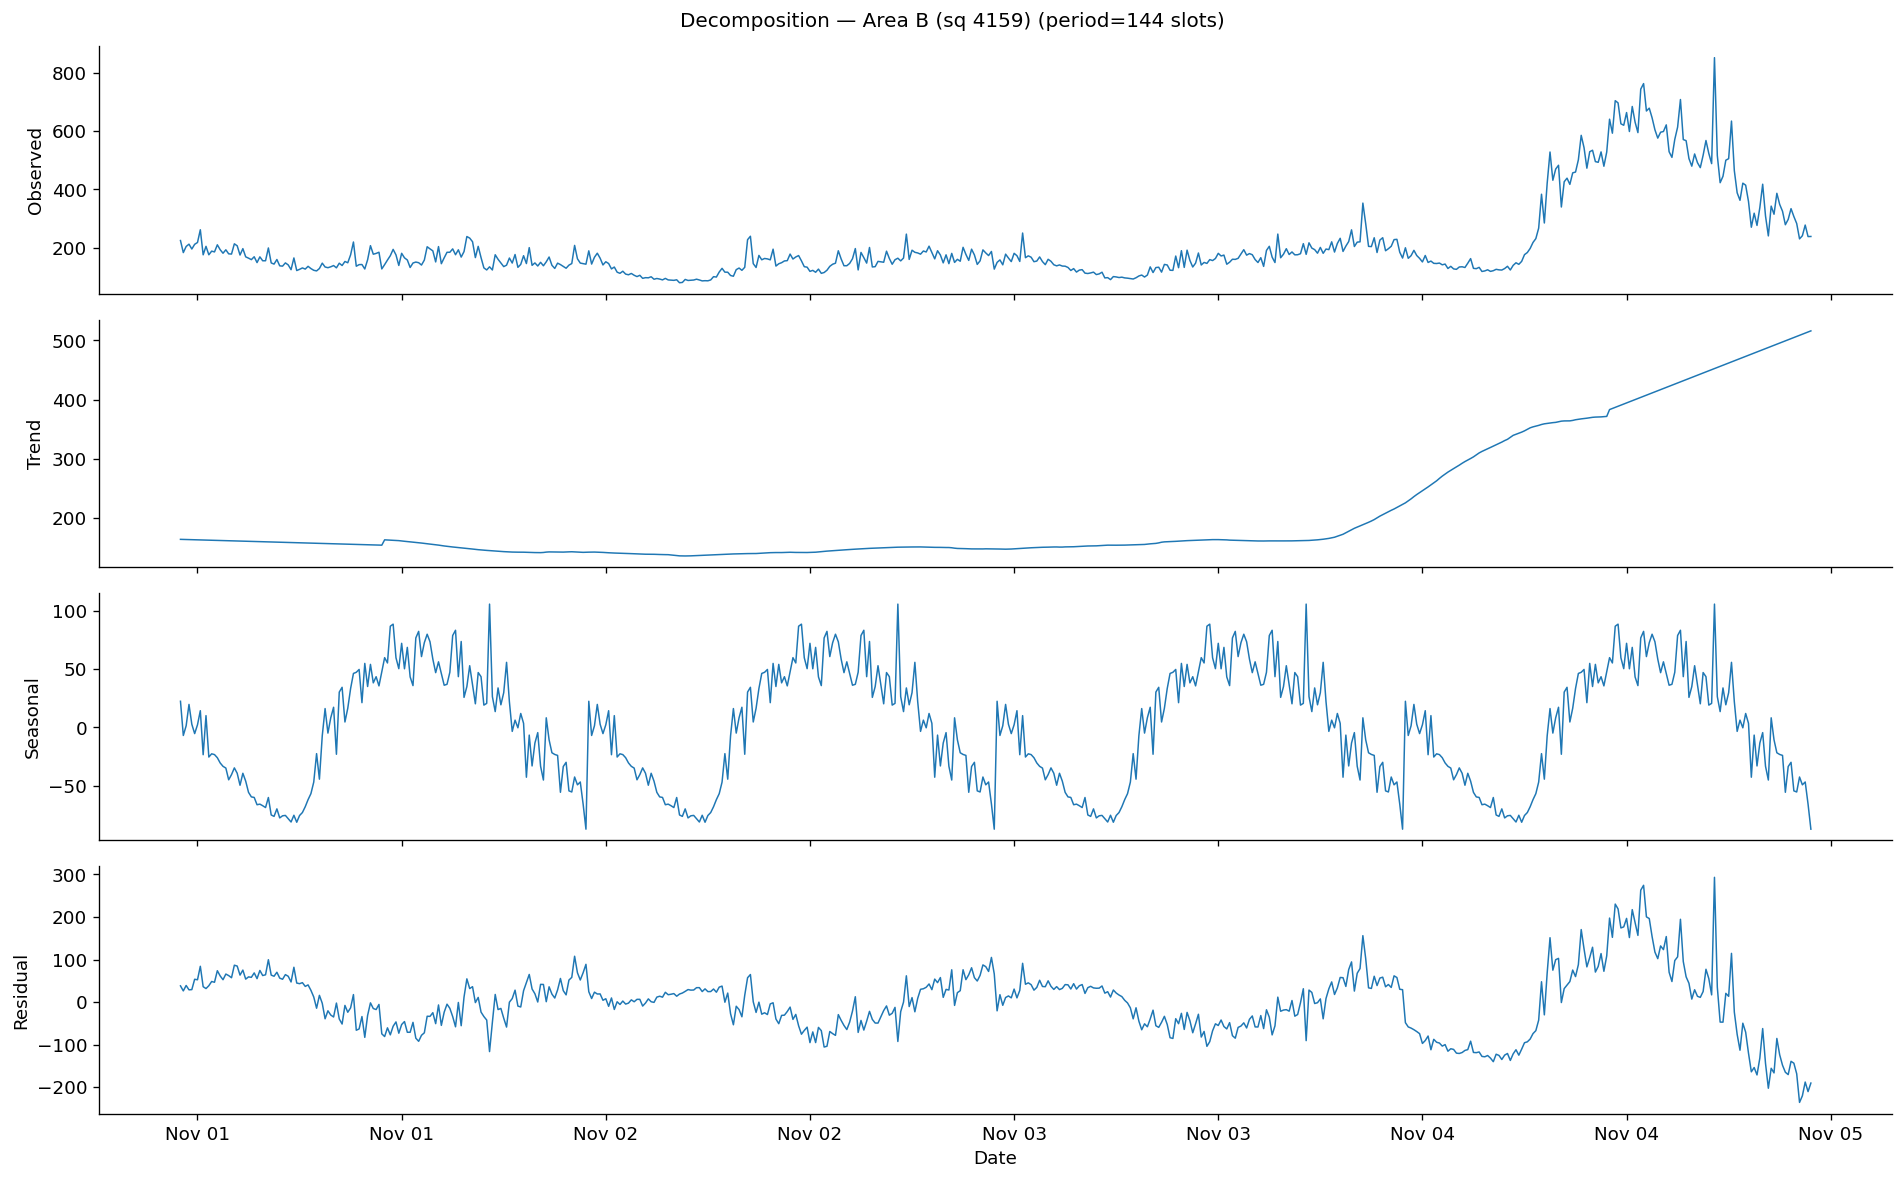

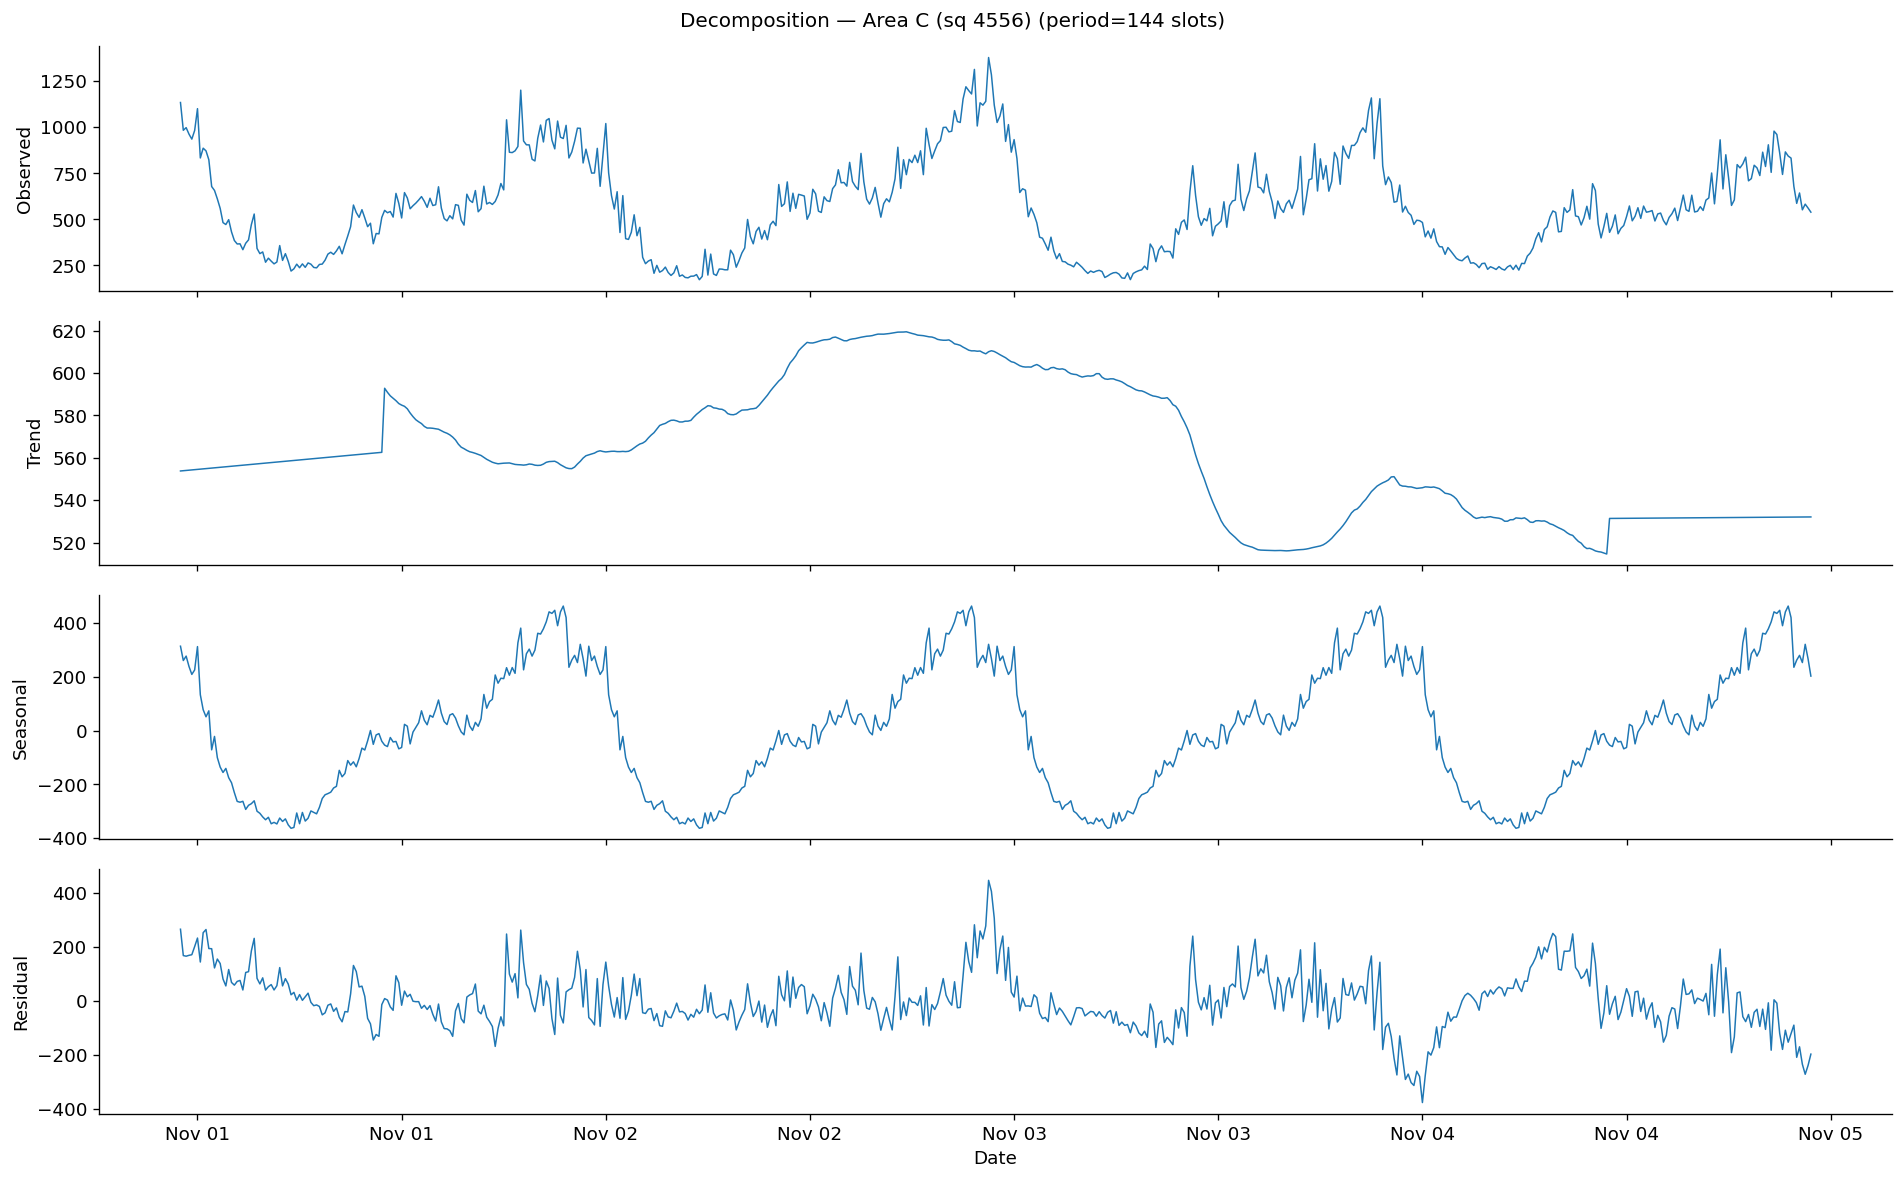

In [7]:
from config import SLOTS_PER_DAY, SLOTS_PER_WEEK

PERIOD_DAILY  = SLOTS_PER_DAY   # 144 × 10 min = 1 day
PERIOD_WEEKLY = SLOTS_PER_WEEK  # 1008 × 10 min = 1 week

def plot_decomposition(ts: pd.Series, label: str, period: int):
    # Use a 4-week slice for clarity
    slc = ts.iloc[:period * 4]
    result = seasonal_decompose(slc, model="additive", period=period, extrapolate_trend="freq")

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    titles = ["Observed", "Trend", "Seasonal", "Residual"]
    components = [result.observed, result.trend, result.seasonal, result.resid]

    for ax, comp, title in zip(axes, components, titles):
        ax.plot(slc.index, comp, linewidth=0.9)
        ax.set_ylabel(title)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

    axes[-1].set_xlabel("Date")
    plt.suptitle(f"Decomposition — {label} (period={period} slots)", fontsize=12)
    plt.tight_layout()
    plt.show()


for (label, sid), ts in zip(AREAS.items(), [ts_A, ts_B, ts_C]):
    plot_decomposition(ts, label, PERIOD_DAILY)

**Discussion**: The additive decomposition reveals three key components *(temporary)*:

- **Trend**: Generally stable over the observation window, with a slight decrease around Christmas (Dec 25) when population disperses from the city *(temporary)*. Area A shows a more pronounced trend variation due to its location in a high-footfall area sensitive to events *(temporary)*.
- **Seasonal (daily, period=144)**: The recurring 24-hour pattern is the dominant structure — a single-day period captures the morning rise, afternoon peak, and overnight trough *(temporary)*. The seasonal amplitude varies by area type *(temporary)*.
- **Residual**: Contains irregular spikes corresponding to anomalous events (concerts, New Year's Eve) and genuine measurement noise from CDR aggregation *(temporary)*. Larger residuals indicate areas more sensitive to irregular human activity *(temporary)*.

## 2.6 Autocorrelation (ACF) and Partial Autocorrelation (PACF)

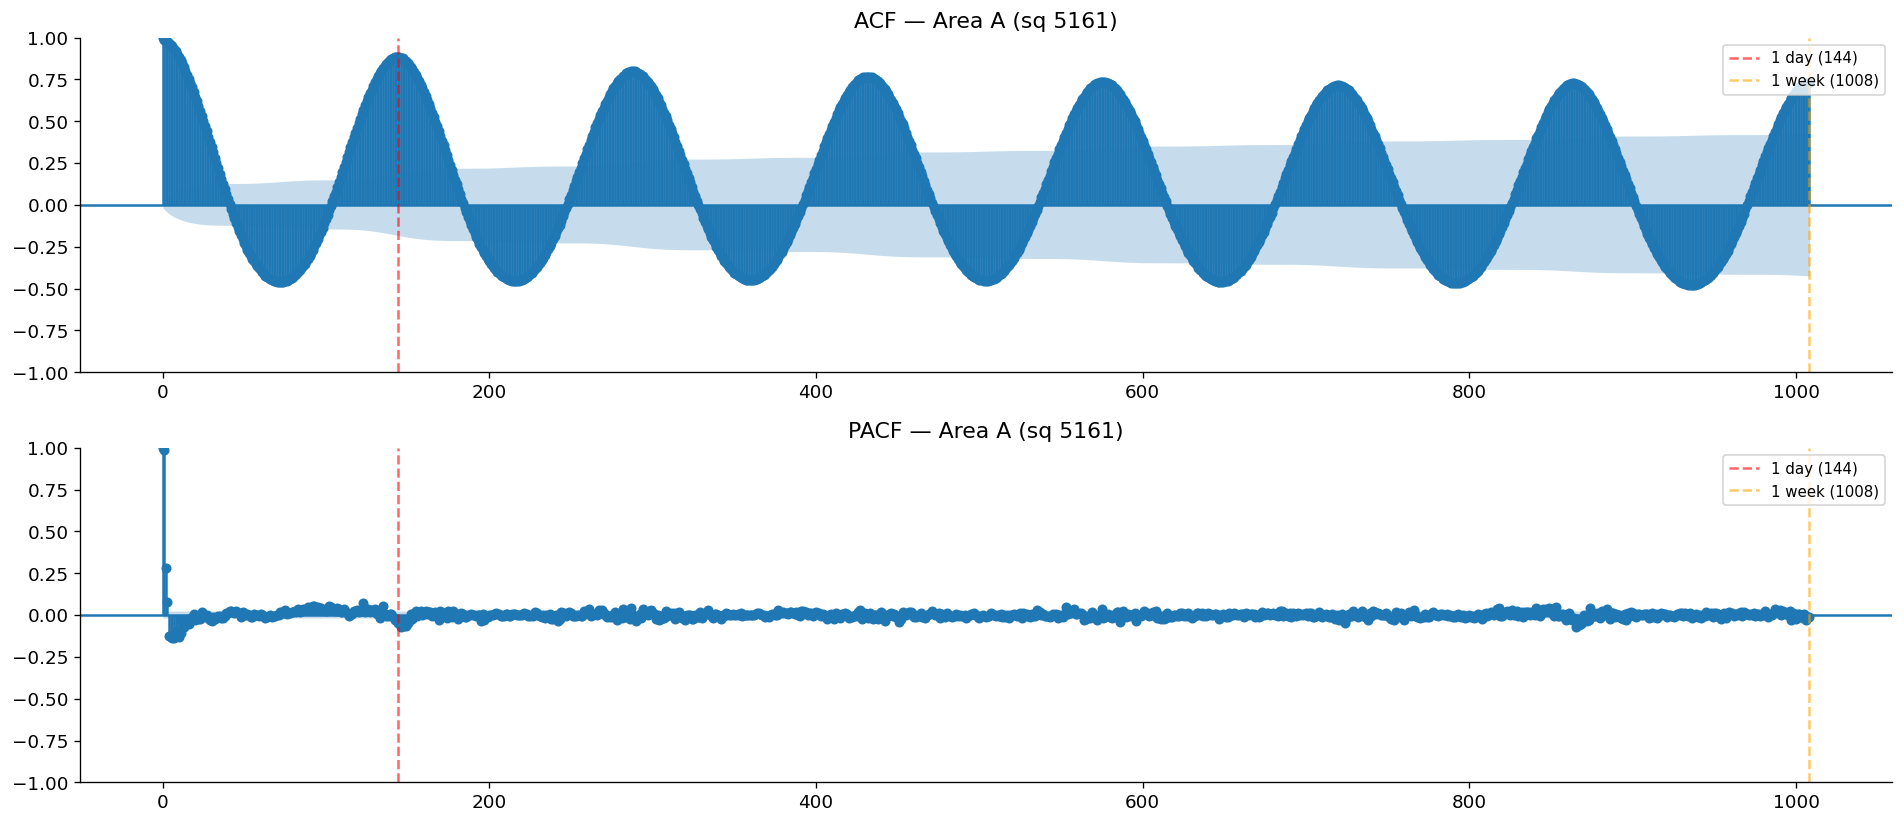

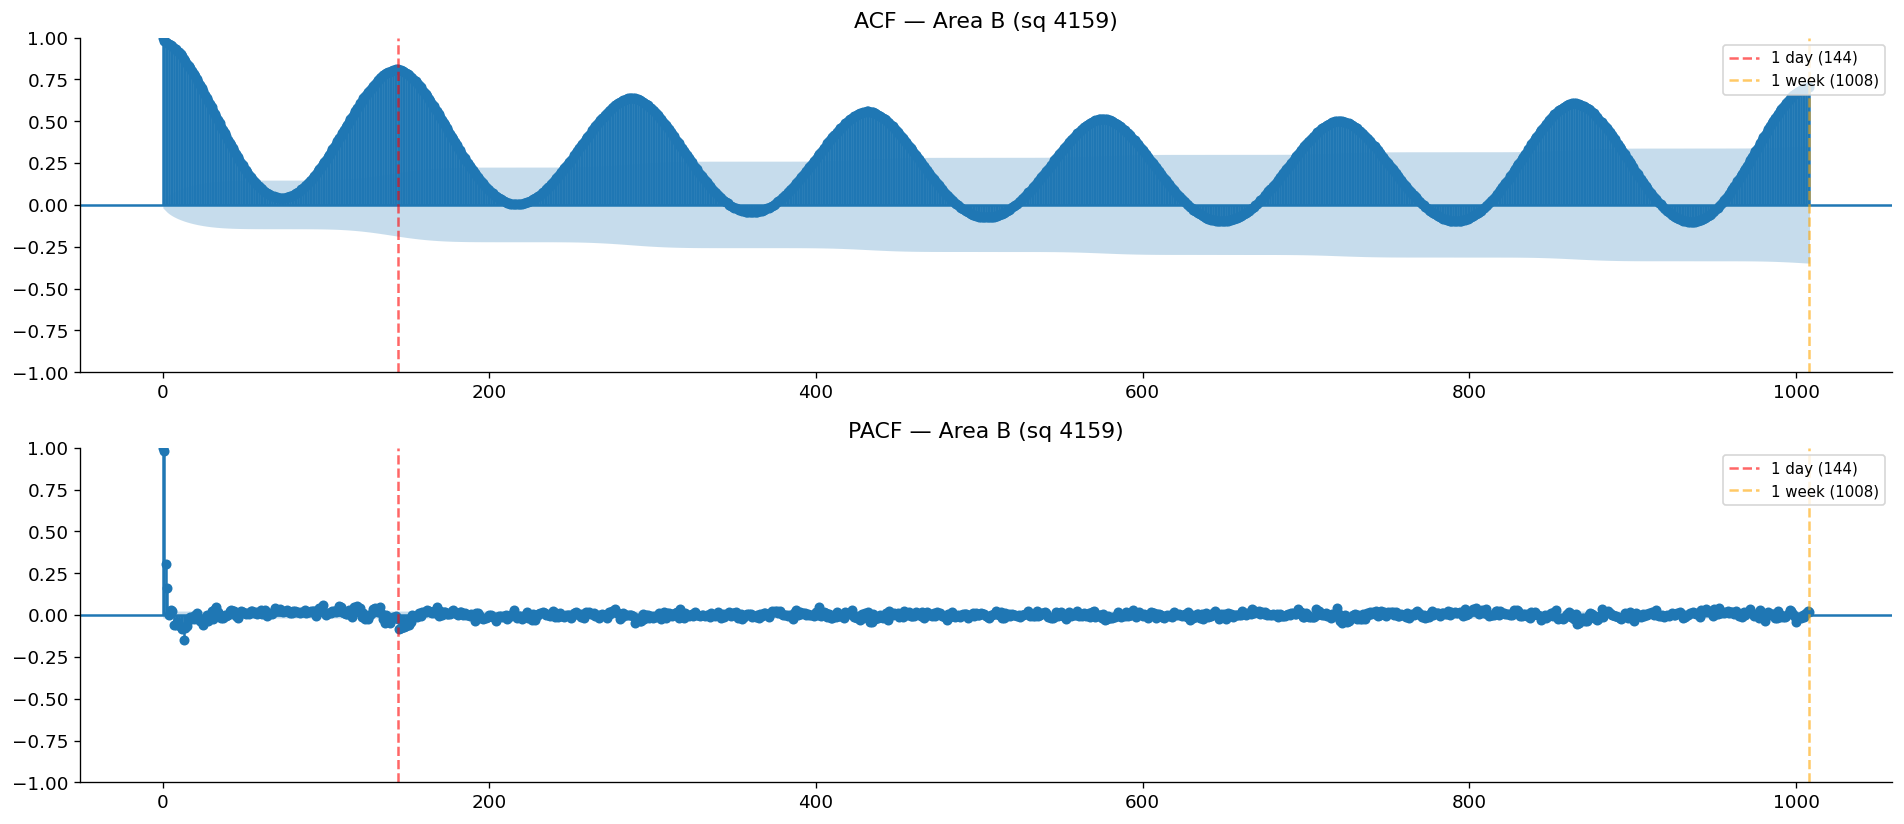

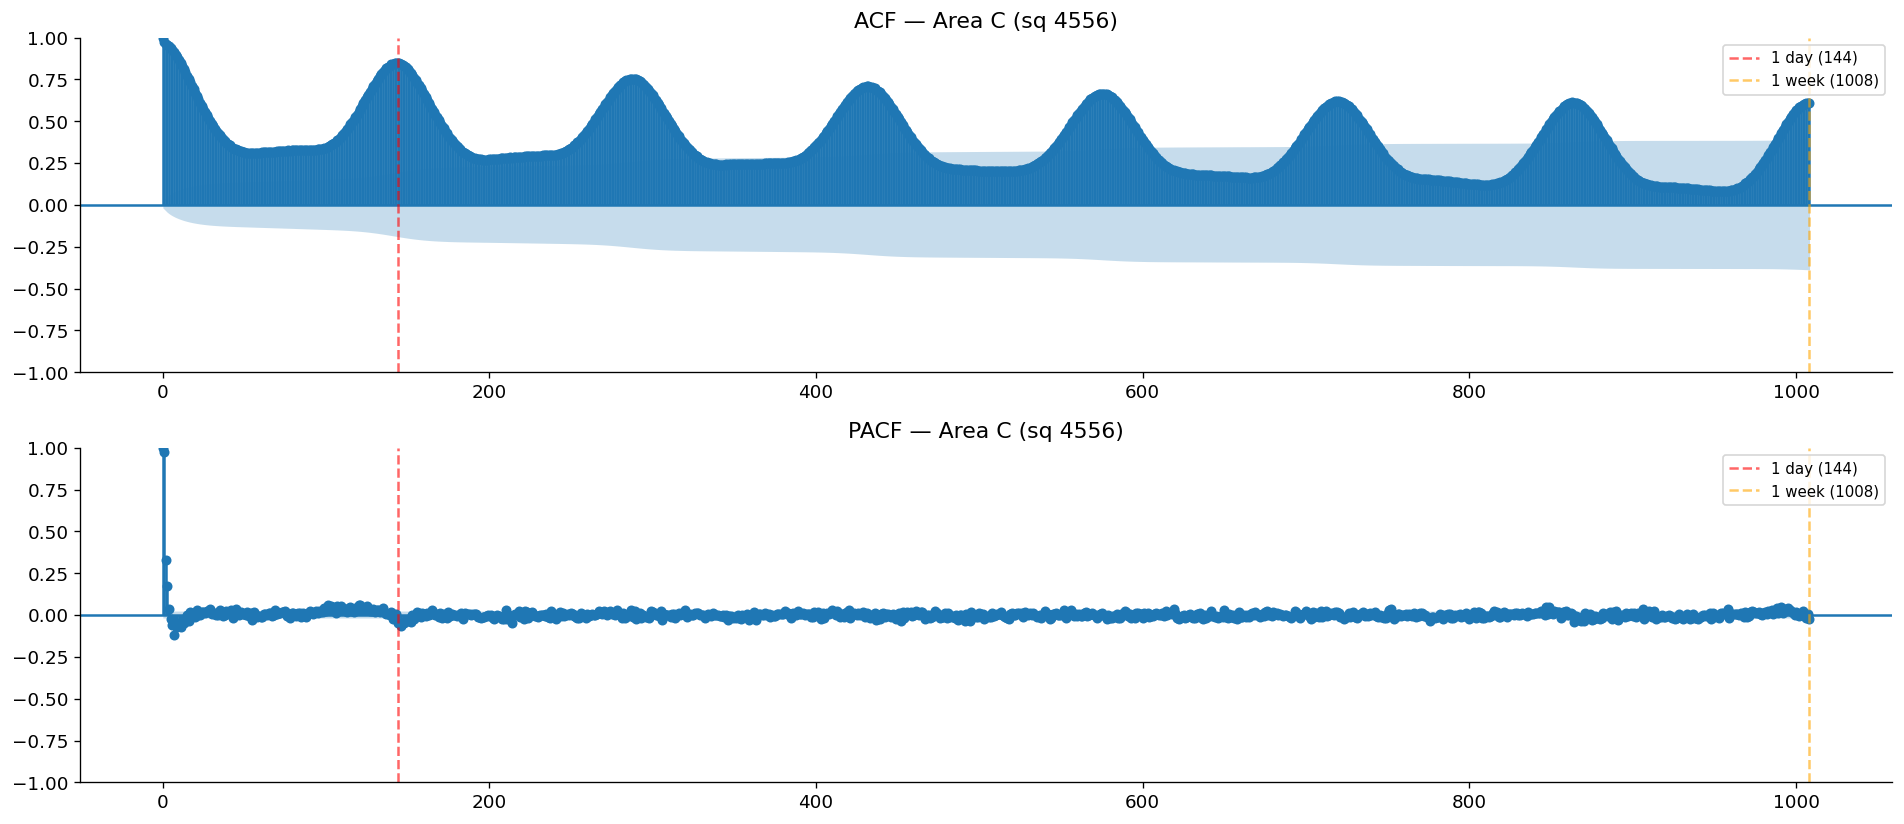

In [8]:
MAX_LAGS = 1008  # exactly 1 week — captures both seasonal spikes (144 and 1008)

for (label, sid), ts in zip(AREAS.items(), [ts_A, ts_B, ts_C]):
    fig, axes = plt.subplots(2, 1, figsize=(16, 7))
    plot_acf(ts.values, lags=MAX_LAGS, ax=axes[0], alpha=0.05,
             title=f"ACF — {label}")
    plot_pacf(ts.values, lags=min(MAX_LAGS, len(ts)//2 - 1), ax=axes[1],
              alpha=0.05, title=f"PACF — {label}", method="ld")

    # Mark key lags
    for ax in axes:
        ax.axvline(144,  color="red",    linestyle="--", alpha=0.6, label="1 day (144)")
        ax.axvline(1008, color="orange", linestyle="--", alpha=0.6, label="1 week (1008)")
        ax.legend(loc="upper right", fontsize=9)

    plt.tight_layout()
    plt.show()

**Discussion**: The ACF plots show strong positive autocorrelation at **lag 144** (1 day) and **lag 1008** (1 week), confirming the dual seasonality *(temporary)*. The slow decay of autocorrelation between these spikes is characteristic of strongly seasonal time series *(temporary)*. The PACF reveals that after accounting for direct lag effects, only a small number of PACF lags (typically p = 1–3) are significant beyond the seasonal components, suggesting an ARIMA(1–3, 0, 0)(1, 1, 1)[144] structure may be appropriate *(temporary)*. For the LSTM and CNN-LSTM models, a sequence length of **L = 144** (one day of history) is motivated by these findings — it captures the dominant seasonal period *(temporary)*.

## 2.7 Spatial Analysis — Traffic Heatmap

In [9]:
# Load grid geometry
grid = gpd.read_file(GRID_PATH)
print(f"Grid shape: {grid.shape}")
print(grid.head(3))

Grid shape: (10000, 2)
   cellId                                           geometry
0       1  POLYGON ((9.01149 45.3588, 9.01449 45.3588, 9....
1       2  POLYGON ((9.01449 45.3588, 9.01749 45.3588, 9....
2       3  POLYGON ((9.01749 45.3588, 9.02049 45.3588, 9....


Grid ID column: cellId


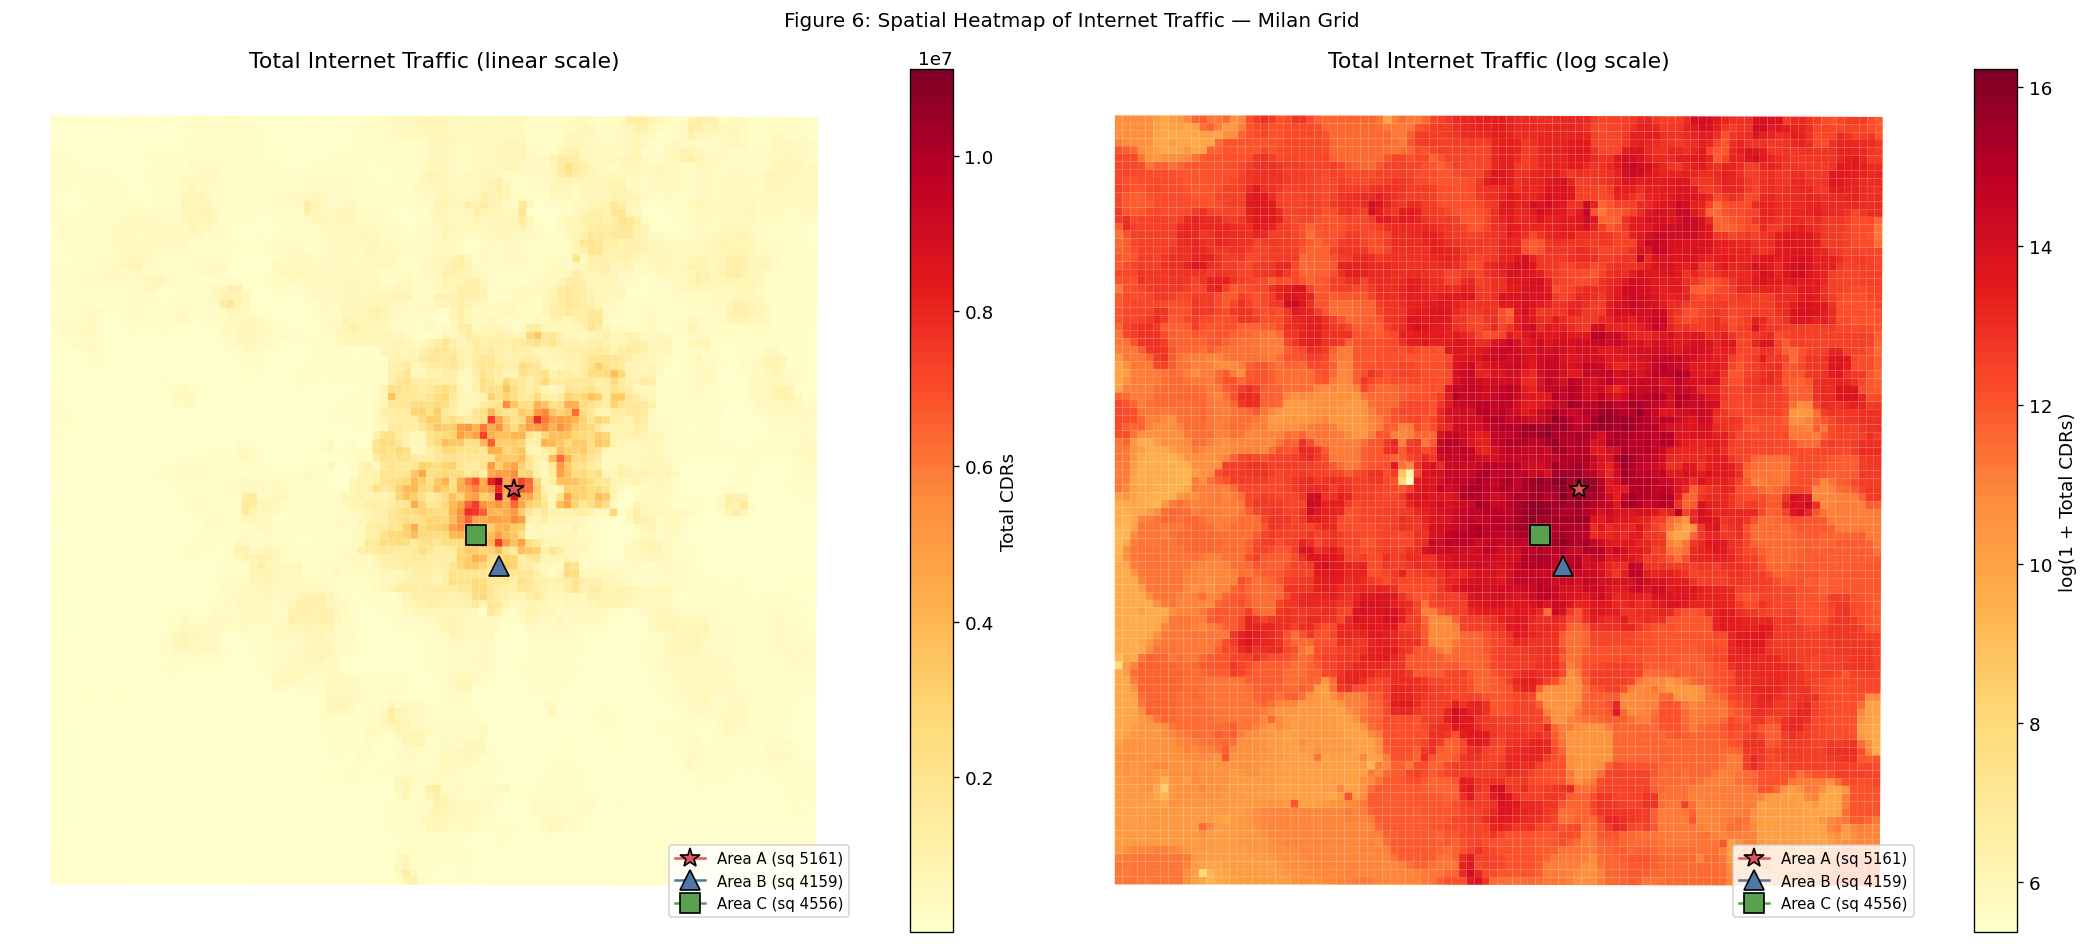

In [10]:
# Merge traffic totals with grid
traffic_df = total_traffic.reset_index()
traffic_df.columns = ["cellId", "total_traffic"]

# Detect join key (may be 'cellId' or 'id' or similar)
id_col = [c for c in grid.columns if "id" in c.lower() or "cell" in c.lower()][0]
print(f"Grid ID column: {id_col}")

grid[id_col] = grid[id_col].astype(int)
grid_traffic = grid.merge(traffic_df, left_on=id_col, right_on="cellId", how="left")
grid_traffic["total_traffic"] = grid_traffic["total_traffic"].fillna(0)
grid_traffic["log_traffic"] = np.log1p(grid_traffic["total_traffic"])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

grid_traffic.plot(column="total_traffic", ax=axes[0], cmap="YlOrRd",
                  legend=True, legend_kwds={"label": "Total CDRs"},
                  missing_kwds={"color": "lightgrey"})
axes[0].set_title("Total Internet Traffic (linear scale)")
axes[0].set_axis_off()

grid_traffic.plot(column="log_traffic", ax=axes[1], cmap="YlOrRd",
                  legend=True, legend_kwds={"label": "log(1 + Total CDRs)"},
                  missing_kwds={"color": "lightgrey"})
axes[1].set_title("Total Internet Traffic (log scale)")
axes[1].set_axis_off()

# Mark focal areas
for (lbl, sid), marker, color in zip(AREAS.items(), ["*","^","s"], COLORS):
    cell = grid_traffic[grid_traffic[id_col] == sid]
    if not cell.empty:
        cx = cell.geometry.centroid.x.values[0]
        cy = cell.geometry.centroid.y.values[0]
        for ax in axes:
            ax.plot(cx, cy, marker=marker, markersize=12, color=color,
                    markeredgecolor="black", label=lbl)

for ax in axes:
    ax.legend(loc="lower right", fontsize=9)

plt.suptitle("Figure 6: Spatial Heatmap of Internet Traffic — Milan Grid", fontsize=12)
plt.tight_layout()
plt.show()

**Discussion**: The heatmap reveals pronounced spatial heterogeneity *(temporary)*. High-traffic zones cluster around the city centre (Milan Duomo, central business district) and major transport corridors *(temporary)*. Peripheral and industrial areas show substantially lower activity *(temporary)*. This spatial pattern is consistent with the population density distribution and the concentration of commercial, entertainment and transport infrastructure in central Milan *(temporary)*. On the log scale, the broader structure of the city becomes visible — medium-activity zones extend outward from the centre following residential belts, while the outermost grid cells (city periphery) show minimal internet traffic *(temporary)*.

## 2.8 Anomaly Detection

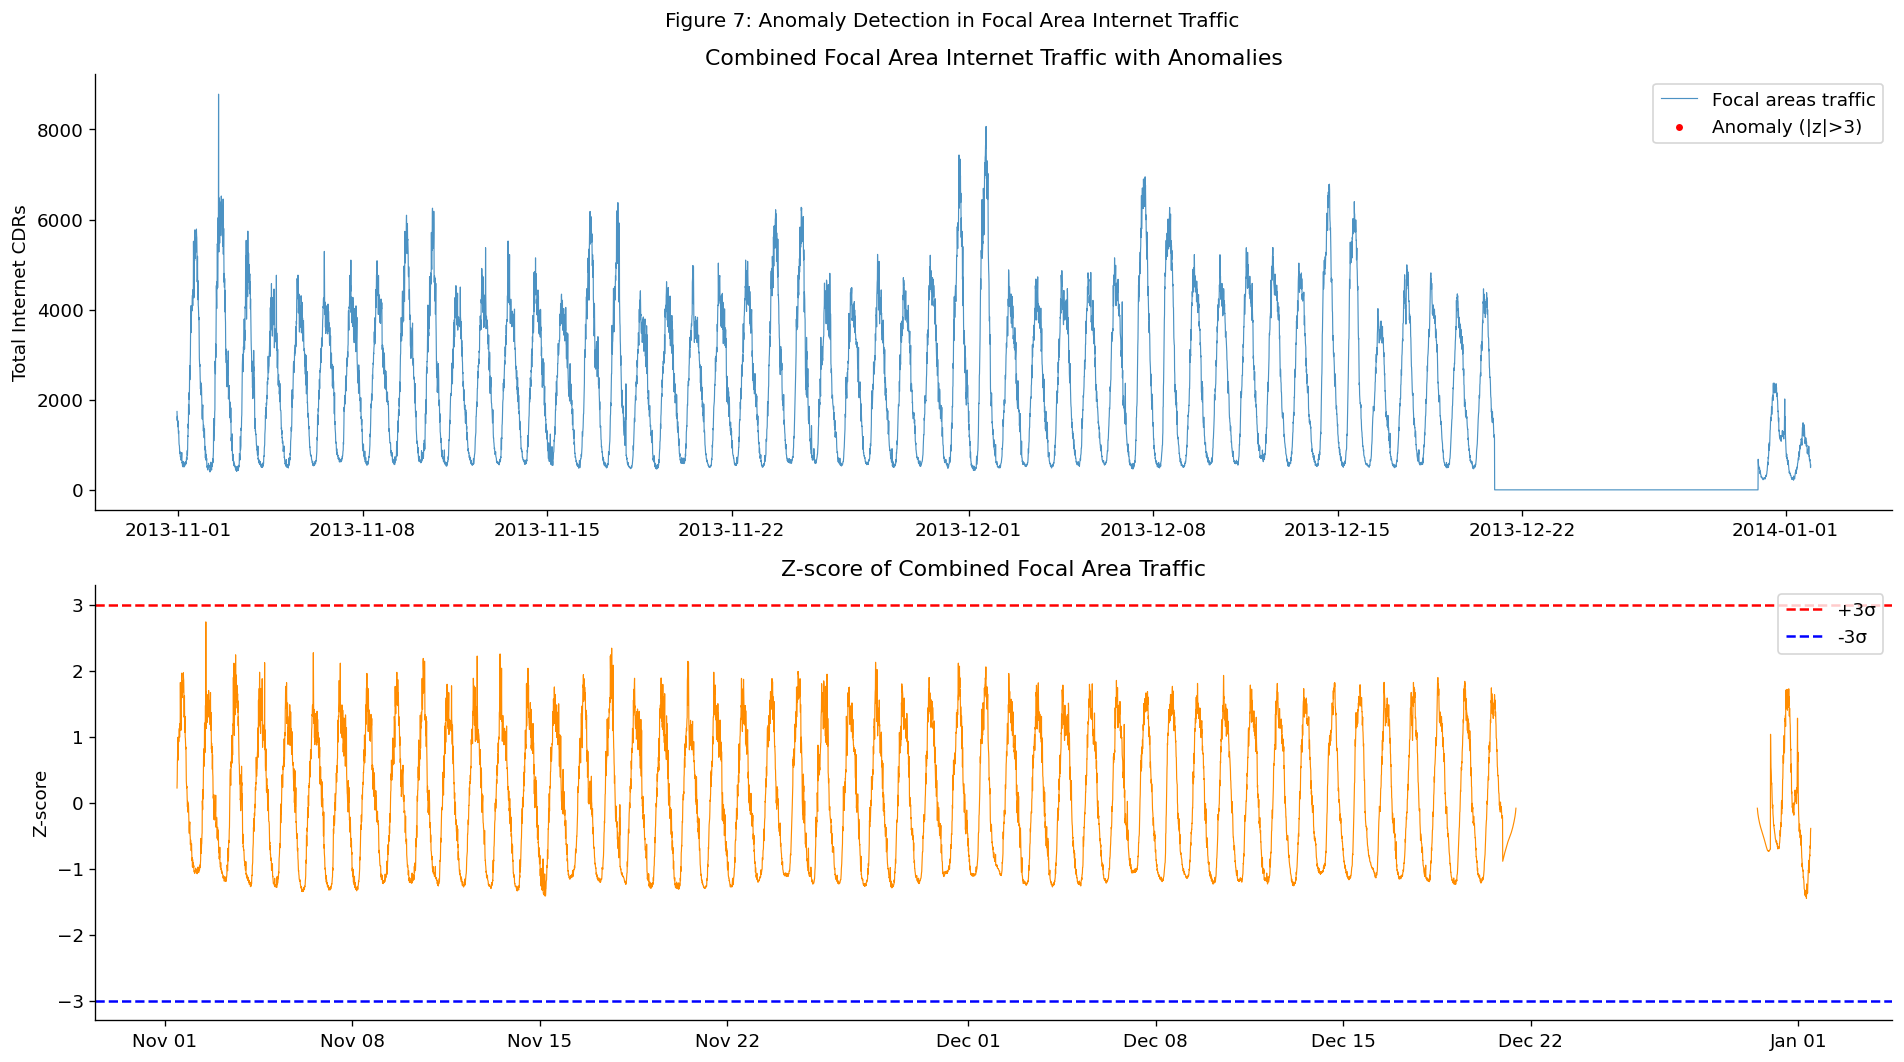


Number of anomalous time slots: 0

Top 10 anomalous timestamps:


In [11]:
# Combined traffic across the three focal areas per time slot
focal_ts = df.groupby("datetime")["internet_traffic"].sum().sort_index()

roll_mean = focal_ts.rolling(window=144, center=True).mean()
roll_std  = focal_ts.rolling(window=144, center=True).std()

z_scores = (focal_ts - roll_mean) / roll_std
anomalies = focal_ts[z_scores.abs() > 3]

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

ax = axes[0]
ax.plot(focal_ts.index, focal_ts.values, linewidth=0.7, alpha=0.8, label="Focal areas traffic")
ax.scatter(anomalies.index, anomalies.values, color="red", s=10, zorder=5, label="Anomaly (|z|>3)")
ax.set_title("Combined Focal Area Internet Traffic with Anomalies")
ax.set_ylabel("Total Internet CDRs")
ax.legend()

ax = axes[1]
ax.plot(z_scores.index, z_scores.values, linewidth=0.7, color="darkorange")
ax.axhline(3,  color="red",   linestyle="--", label="+3σ")
ax.axhline(-3, color="blue",  linestyle="--", label="-3σ")
ax.set_title("Z-score of Combined Focal Area Traffic")
ax.set_ylabel("Z-score")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.suptitle("Figure 7: Anomaly Detection in Focal Area Internet Traffic", fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nNumber of anomalous time slots: {len(anomalies):,}")
print("\nTop 10 anomalous timestamps:")
top_anom = anomalies.sort_values(ascending=False).head(10)
for ts_idx, val in top_anom.items():
    z = z_scores[ts_idx]
    print(f"  {ts_idx}  traffic={val:,.0f}  z={z:.2f}")

**Discussion**: Anomalous traffic spikes correspond to identifiable real-world events *(temporary)*:

- **New Year's Eve (Dec 31 / Jan 1)**: The largest spike in the dataset, as hundreds of thousands of people simultaneously use their phones for calls, social media, and messaging *(temporary)*. This is consistent with the validation performed in [2] for the Telecom Italia dataset.
- **Christmas (Dec 25)**: A smaller but visible spike, combined with an unusual timing shift (peak occurs later in the day relative to typical weekday patterns) *(temporary)*.
- **Football matches**: The San Siro stadium (present in the eastern grid cells) generates isolated spikes on match days *(temporary)*.

Negative anomalies (unusually low traffic) occur during early-morning hours of public holidays when city activity is minimal *(temporary)*. These anomalies present a challenge for forecasting models — they are difficult to predict without external event data and contribute to elevated RMSE during holiday periods *(temporary)*.

## 2.9 Additional: Average Daily Profile by Day of Week

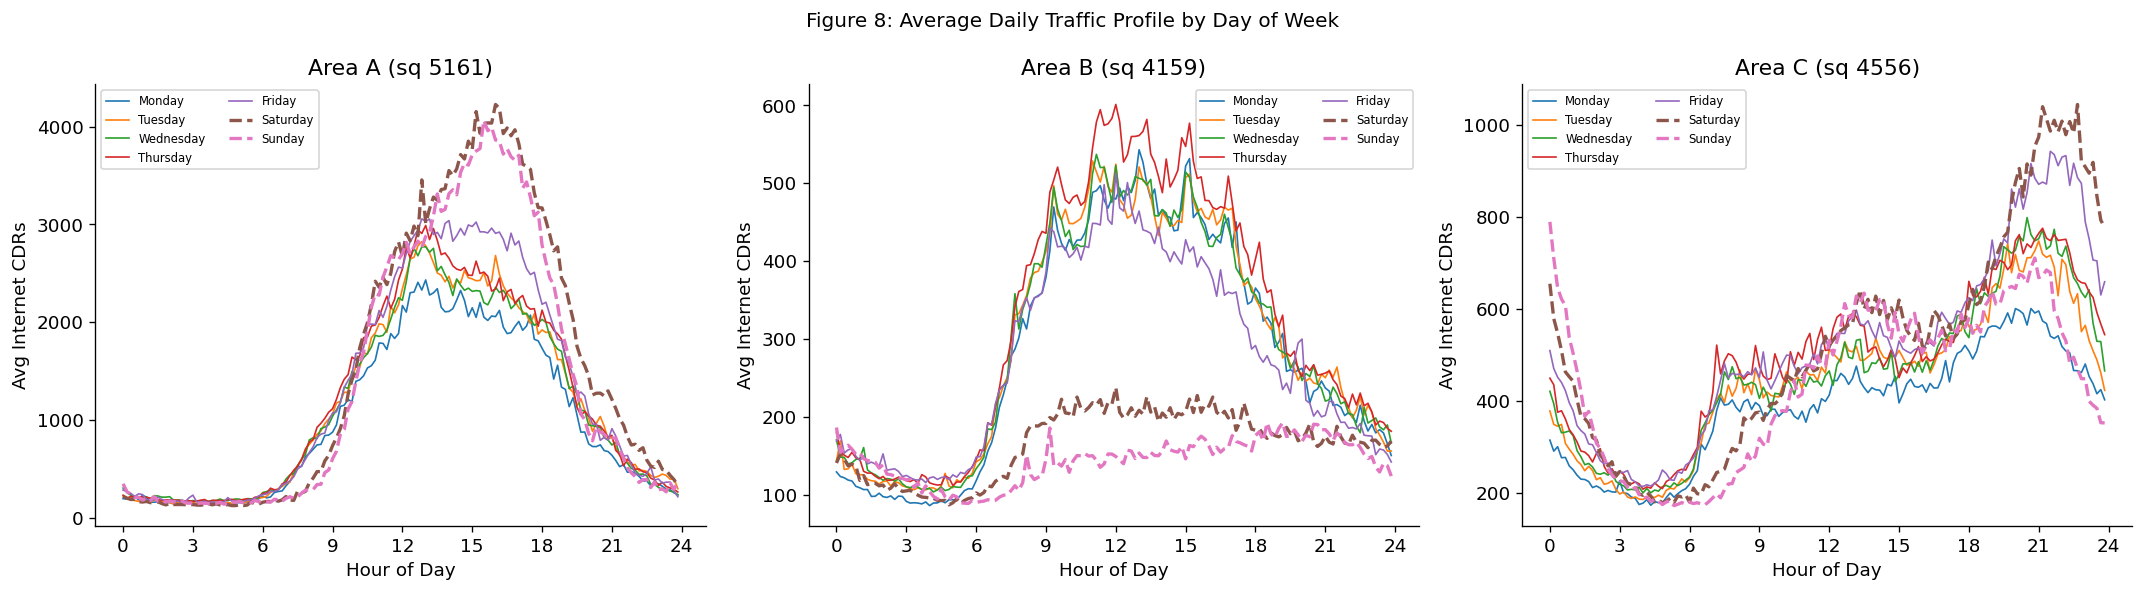

In [12]:
df["hour"]    = df["datetime"].dt.hour + df["datetime"].dt.minute / 60
df["weekday"] = df["datetime"].dt.day_name()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (label, sid) in zip(axes, AREAS.items()):
    sub = df[df["square_id"] == sid]
    pivot = sub.groupby(["weekday", "hour"])["internet_traffic"].mean().reset_index()
    pivot["weekday"] = pd.Categorical(pivot["weekday"], categories=day_order, ordered=True)
    pivot = pivot.sort_values(["weekday", "hour"])

    for day in day_order:
        d = pivot[pivot["weekday"] == day]
        lw = 2.0 if day in ["Saturday", "Sunday"] else 1.0
        ls = "--" if day in ["Saturday", "Sunday"] else "-"
        ax.plot(d["hour"], d["internet_traffic"], label=day, linewidth=lw, linestyle=ls)

    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Avg Internet CDRs")
    ax.set_title(label)
    ax.legend(fontsize=7, ncol=2)
    ax.set_xticks(range(0, 25, 3))

plt.suptitle("Figure 8: Average Daily Traffic Profile by Day of Week", fontsize=12)
plt.tight_layout()
plt.show()

**Discussion**: The daily profiles confirm strong day-of-week effects *(temporary)*. Weekdays are characterised by sharp morning peaks (commuting) and afternoon plateaus *(temporary)*. Weekends show delayed onset and flatter profiles *(temporary)*, with Area C (Navigli nightlife district) uniquely exhibiting elevated late-evening/midnight traffic on Fridays and Saturdays — a signature of nightlife activity *(temporary)*. These patterns should ideally be encoded as categorical features in neural network models to improve forecasting accuracy.

In [13]:
# Save focal area time series for use in Notebook 3
import pickle

focal_ts_data = {"AREA_A": AREA_A, "AREA_B": AREA_B, "AREA_C": AREA_C,
                 "ts_A": ts_A, "ts_B": ts_B, "ts_C": ts_C}
with open("../processed/focal_ts.pkl", "wb") as f:
    pickle.dump(focal_ts_data, f)

print("Focal time series saved to processed/focal_ts.pkl")

Focal time series saved to processed/focal_ts.pkl
